In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


## Load Data

In [2]:
def transform_counts_data(counts_data, method="clr"):
    """
    Transform the counts data using either CLR or Relative Abundance followed by log transformation.

    Parameters:
    counts_data (pd.DataFrame): The input counts data.
    method (str): The transformation method to use. Options are 'clr' for CLR transformation and
                  'relative_abundance' for relative abundance followed by log transformation.

    Returns:
    pd.DataFrame: The transformed counts data.
    """
    if method == "clr":
        # Perform CLR transformation
        df_mb = pd.DataFrame(clr(counts_data.replace(0, 1)))
        df_mb.index = counts_data.index
        df_mb.columns = counts_data.columns
    elif method == "relative_abundance":
        # Perform relative abundance transformation followed by log transformation
        df_mb = counts_data.div(counts_data.sum(axis=1), axis=0)  # Relative abundance
        # df_mb = np.log10(df_mb + 1e-6)  # Log transformation
    else:
        raise ValueError("Invalid method. Choose either 'clr' or 'relative_abundance'.")

    return df_mb

In [3]:
def create_quartiles(df, column_name, q=4):
    """
    Create quartiles for a numerical column in a pandas DataFrame.

    Parameters:
    - df: pandas.DataFrame containing the data.
    - column_name: String, the name of the column to be binned into quartiles.
    - q: Integer, the number of quantiles. Default is 4 (quartiles).

    Returns:
    - A pandas Series with the quartile assignment for each entry in the column.
    """
    quartiles = pd.qcut(df[column_name], q, labels=[f"Q{i}" for i in range(1, q + 1)])
    return quartiles.astype(str)

In [4]:
meta = pd.read_csv("../../data/fay_meta_diets.csv", index_col=0)

#### ASV data

In [5]:
path_asv_taxonomy = "../../qiime/taxonomy_rarefied-table_2024_09/taxonomy.tsv"

otuID_taxonomy = pd.read_csv(path_asv_taxonomy, sep="\t", index_col=0)
otuID_taxonomy.head()

## make dictionary of taxonomy
taxonomy_dict = {index: row["Taxon"] for index, row in otuID_taxonomy.iterrows()}

In [6]:
otuID_taxonomy.head()

,Taxon,Confidence
Feature ID,,
9ffbd6e66ae2e988ff107ea32f41e2af,d__Bacteria; p__Bacillota_A_368345; c__Clostri...,1.0
f0a47a9c0d66915a6495a904d8db42e3,d__Bacteria; p__Bacillota_A_368345; c__Clostri...,1.0
4a84fe03b6cea256947438079103ab1a,d__Bacteria; p__Bacillota_A_368345; c__Clostri...,1.0
a5247083655f4c613f6b9bfc5d28cf94,d__Bacteria; p__Bacillota_A_368345; c__Clostri...,1.0
dc9c55e36f5c77f976ae9e5923f0138f,d__Bacteria; p__Bacillota_A_368345; c__Clostri...,1.0


In [7]:
path_counts_data = "../../qiime/table_rarefied.tsv"
counts_data = pd.read_csv(path_counts_data, sep="\t", index_col=0, skiprows=1).T

transformed_counts_data = transform_counts_data(
    counts_data, method="relative_abundance"
)
counts_data.head()

#OTU ID,8937656c16c20701c107e715bad86732,59196a586276f0be745d0e334fc071c6,ad52a0f6646c574417ce0b13b84acfa9,877f27b47c85f6b2d3cf8a6aa86def40,6c7fa77831ae630967a6fbfc8ee47901,f7686a74ca2d3729eb66305e8a26309b,149e7d5e484d157f2ac6140a2111618e,d061a99148d649c4eca4836c5f4b5b68,959d48a11e3b26c9268f0bd1dae6ec40,447b9d6a5c17543a456c597e65b37139,...,e8ef94f9b7b8c1cb5001b1a849d01a0a,f0efa9c8508f32a3aa10311f7dd5db49,ec2340c4a91f1043faf094b25f29ff83,fba0445d13e83396c5352d9361afe105,e0c7c5f7245986a1a04669cba113d2a5,c1eba7376458ac99a6cd37b64f98fbbf,c4ea259e761b45dd1ee4b6adf054ba4c,3095829f9daf397ac86963f336d6f787,3572535b3b200557e458d78fbd3aca13,44e6ec02726d6328dcf67a42a5ddccab
sample30489,1735.0,950.0,711.0,637.0,631.0,578.0,414.0,365.0,313.0,276.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample30706,501.0,385.0,1082.0,377.0,279.0,289.0,20.0,54.0,574.0,75.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample30666,236.0,487.0,382.0,99.0,213.0,216.0,178.0,2.0,236.0,263.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample15977,415.0,777.0,0.0,33.0,563.0,249.0,0.0,127.0,132.0,195.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample30750,452.0,190.0,57.0,241.0,46.0,25.0,0.0,14.0,177.0,103.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Fetching Prevalence Data for ASV name annotation

In [8]:
prevalence = pd.read_csv(
    "../../data/prevalence_microbes.csv",
).set_index("#OTU ID")
prevalence = pd.Series(
    prevalence["0"].values, index=prevalence.index
)  ## make series of prevalence

dict_ASV_names = dict(
    zip(
        prevalence.sort_values(ascending=False).index,
        ["ASV_" + str(i) for i in range(len(prevalence))],
    )
)

print("prevalence shape: ", prevalence.shape)
prevalence.head()

prevalence shape:  (12518,)


#OTU ID
8937656c16c20701c107e715bad86732    0.858871
59196a586276f0be745d0e334fc071c6    0.983871
ad52a0f6646c574417ce0b13b84acfa9    0.740927
877f27b47c85f6b2d3cf8a6aa86def40    0.796371
6c7fa77831ae630967a6fbfc8ee47901    0.986895
dtype: float64

## Birdman Plotting Functions

In [9]:
def _unpack_hdi_and_filter(df, col):
    df[["lower", "upper"]] = df[col].str.split(",", expand=True)
    # remove ( from lower and ) from upper and convert to float
    df.lower = df.lower.str[1:].astype("float")
    df.upper = df.upper.str[:-1].astype("float")

    df["credible"] = np.where((df.lower > 0) | (df.upper < 0), "yes", "no")

    df.upper = df.upper - df[col.replace("hdi", "mean")]
    df.lower = df[col.replace("hdi", "mean")] - df.lower

    return df


def _get_top_n_feats(df, n):
    if df.shape[0] < 2 * n:
        df_for_display = df
    else:
        bottomn = df[:n]
        topn = df[-1 * n :]
        df_for_display = pd.concat([bottomn, topn])

    return df_for_display


def _display_top_n_feats(df, n, yvar, xvar, xlab, ylab, title):
    if df.shape[0] < 2 * n:
        df_for_display = df
    else:
        bottomn = df[:n]
        topn = df[-1 * n :]
        df_for_display = pd.concat([bottomn, topn])

    # Create color list based on x values
    colors = ["darkorange" if x < 0 else "purple" for x in df_for_display[xvar]]

    # Plot points with colors
    sns.stripplot(data=df_for_display, y=yvar, x=xvar, palette=colors)

    # Plot error bars with colors for each point
    for idx, row in df_for_display.iterrows():
        color = "darkorange" if row[xvar] < 0 else "purple"
        plt.errorbar(
            x=row[xvar],
            y=row[yvar],
            xerr=[[row["lower"]], [row["upper"]]],
            ls="none",
            color=color,
            alpha=0.5,
        )

    plt.grid(axis="y", color="grey", linestyle="--", linewidth=0.3)
    plt.axvline(x=0, color="grey", linestyle="--", linewidth=0.8)
    plt.ylabel("")
    plt.xlabel(xlab, fontsize=12)
    plt.title(title)


def birdman_plot_single_var(
    df_inf,
    var,
    action="plot",
    n=50,
    plot_path=None,
    annotate_plot_args={"textpos": (0.3, 0.95), "text": ""},
):
    sub_df = _unpack_hdi_and_filter(df_inf, var + "_hdi")
    sub_df.rename_axis(index="Feature", inplace=True)
    sub_df = sub_df.sort_values(by=var + "_mean")
    # print("Filtered Shape: " + str(sub_df.loc[sub_df["credible"] == "yes"].shape))

    xlab = "Mean Effect Size for " + process_string(var)  # e.g. var = "host_age[T.34]_"
    ylab = "Features"
    df_for_display = sub_df.reset_index()
    df_for_display = df_for_display.loc[df_for_display.credible == "yes"]

    if action == "plot":
        df_for_display["Feature"] = df_for_display["Feature"].map(taxonID_shortName)
        fig, ax = plt.subplots(figsize=(6, 10))
        _display_top_n_feats(
            df_for_display,
            n,
            "Feature",
            var + "_mean",
            xlab,
            ylab,
            process_string(var) + f" (Top {n} and Bottom {n} Features)",
        )
        ax.text(
            annotate_plot_args["textpos"][0],
            annotate_plot_args["textpos"][1],
            annotate_plot_args["text"],
            transform=ax.transAxes,
            fontsize=16,
            fontweight="bold",
            va="top",
            ha="left",
        )
        if plot_path is not None:
            plt.savefig(plot_path, dpi=300, bbox_inches="tight")
            plt.close()
    elif action == "get_top_n":
        return _get_top_n_feats(df_for_display, n)
    else:
        raise ValueError("Invalid action")

## Name Processing

In [10]:
def taxonID_shortName(featureID, level="genus"):
    """
    Shorten the name of a taxa to the genus or species level if possible.
    """
    taxa_name = otuID_taxonomy.loc[featureID].values[0].replace("; ", ";")
    asv_id = dict_ASV_names[featureID]

    regular = shorten_taxa_name(extract_taxa_name(taxa_name, level))
    # regular = regular + " (" + asv_id + ")"
    regular = asv_id + " (" + regular + ")"

    if (
        regular.startswith("g__COE1")
        or regular.startswith("s__UBA")
        or regular.startswith("g__G11")
        or regular.startswith("g__C-53")
    ):
        return shorten_taxa_name(extract_taxa_name(taxa_name, "family")) + ";" + regular
    elif (
        regular.startswith("s__CAG")
        or regular.startswith("s__PeH")
        or regular.startswith("g__SFM")
        or regular.startswith("s__QALR01")
    ):
        return shorten_taxa_name(extract_taxa_name(taxa_name, "order")) + ";" + regular

    return regular


def shorten_taxa_name(taxa_name):
    """
    Shorten the name of a taxa to the genus or species level if possible.
    """
    if taxa_name.startswith("species__"):
        return taxa_name.split("__")[1]
    elif taxa_name.startswith("genus__"):
        return taxa_name.split("__")[1]
    elif taxa_name.startswith("family__"):
        return taxa_name.split("__")[1]
    else:
        return taxa_name


def extract_taxa_name(taxonomy_string, level="species"):
    """
    Extracts the name at a specified taxa level from a taxonomy string.
    If the name at that level is absent, it searches higher levels until a name is found.
    """
    # Define the order of levels to facilitate searching upwards
    levels_order = ["domain", "phylum", "class", "order", "family", "genus", "species"]
    levels_abbr = {
        "domain": "d",
        "phylum": "p",
        "class": "c",
        "order": "o",
        "family": "f",
        "genus": "g",
        "species": "s",
    }

    # Split the taxonomy string into components
    taxa_parts = taxonomy_string.split(";")

    # Dictionary to hold each part of the taxonomy with its level as key
    taxa_dict = {}
    for part in taxa_parts:
        taxa_level, _, taxa_name = part.partition("__")
        if taxa_level:  # Check that taxa_level is not empty
            taxa_dict[taxa_level[0]] = taxa_name

    # Search for the desired level and upwards if necessary
    level_abbr = levels_abbr.get(level, "")
    for i in range(levels_order.index(level), -1, -1):
        current_level = levels_order[i]
        if (
            levels_abbr[current_level] in taxa_dict
            and taxa_dict[levels_abbr[current_level]]
        ):
            return (
                f"{levels_abbr[current_level]}__{taxa_dict[levels_abbr[current_level]]}"
            )

    return "Name not found"


def process_string(
    s,
    ignore_vars=[
        "PDI_Quintile",
        "hPDI_Quintile",
        "HEI",
        "BMI",
    ],
    newLineSep=3,
):
    if s in ignore_vars:
        return s
    s = s.replace("_fg", "")
    # Step 1 & 2: Split the string by "_" and replace "_" with a space, then capitalize the first letter
    parts = s.replace("_eaten", "").split("_")
    # capitalized_parts = [part.capitalize() for part in parts]
    capitalized_parts = [part[0].upper() + part[1:] if part else "" for part in parts]

    # Step 3: If there are more than 3 items, insert "\n" in the middle
    if newLineSep and len(capitalized_parts) > newLineSep and "CV" not in s:
        mid_index = len(capitalized_parts) // 2
        processed_string = (
            " ".join(capitalized_parts[:mid_index])
            + "\n"
            + " ".join(capitalized_parts[mid_index:])
        )
    elif "CV" in s:
        processed_string = (
            capitalized_parts[0] + " (" + " ".join(capitalized_parts[1:]) + ")"
        )
    else:
        processed_string = " ".join(capitalized_parts)

    return processed_string


def extract_taxonomy_mapping(dataframe, taxonomy_level, taxon_type="regular"):
    """
    Extracts taxonomy mapping from index strings to a specified taxonomy level.

    Parameters:
    - dataframe: pandas DataFrame with index containing taxonomy strings.
    - taxonomy_level: string, one of 'family', 'class', 'order' indicating the desired taxonomy level.

    Returns:
    - A dictionary mapping full taxonomy strings to their specified taxonomy level.
    """
    taxonomy_level_prefix = {
        "family": "f__",
        "class": "c__",
        "order": "o__",
    }

    # Check if the requested taxonomy level is valid
    if taxonomy_level not in taxonomy_level_prefix:
        raise ValueError(
            f"Invalid taxonomy level: {taxonomy_level}. Choose from 'family', 'class', 'order'."
        )

    prefix = taxonomy_level_prefix[taxonomy_level]
    taxonomy_mapping = {}

    for index_string in dataframe.index:

        if taxon_type == "ASV":
            featureID = index_string
            index_string = otuID_taxonomy.loc[index_string].values[0].replace("; ", ";")

        # Split the string into components based on semicolons
        components = index_string.split(";")

        # Extract the component that starts with the prefix corresponding to the desired taxonomy level
        taxonomy_component = next(
            (component for component in components if component.startswith(prefix)),
            None,
        )

        # Map the full string to the extracted taxonomy component
        # If the component is not found, you can choose to handle it as you see fit (e.g., map to 'Unknown')
        if taxon_type == "ASV":
            taxonomy_mapping[featureID] = (
                taxonomy_component if taxonomy_component else "Unknown"
            )
        else:
            taxonomy_mapping[index_string] = (
                taxonomy_component if taxonomy_component else "Unknown"
            )

    return taxonomy_mapping


def extract_taxonomy_level(taxonomy_str, level):
    """
    Extracts the taxonomy information at a specified level from a given taxonomy string.

    Parameters:
    - taxonomy_str (str): The taxonomy string to be searched.
    - level (str): The taxonomy level to extract (e.g., 'd', 'p', 'c', 'o', 'f', 'g', 's').

    Returns:
    - str: The name of the taxonomy at the specified level, or an empty string if not found.
    """
    # Split the taxonomy string into parts
    parts = taxonomy_str.split(";")

    # Search for the desired level
    for part in parts:
        if part.startswith(level + "__"):
            # Extract and return the taxonomy name without the level prefix
            return part.split("__")[1]
    # Return an empty string if the level is not found
    return ""

### Computing Log Ratios

In [11]:
from scipy.stats import pearsonr


def compute_log_ratios_using_significant_features(
    counts_data, var, significant_feats, meta, var_list
):
    """
    Compute log ratios using significant features.

    Parameters:
    counts_data (pd.DataFrame): The counts data.
    significant_feats (pd.DataFrame): The significant features.
    var (str): The variable to compute log ratios for.
    meta (pd.DataFrame): The metadata.

    Returns:
    log_ratios (pd.DataFrame): A DataFrame with log ratios for each feature and sample.
    corr (float): The pearson correlation between the log ratios and the variable.
    corr_dict (dict): A dictionary with the pearson correlation and p-value between the log ratios and each variable in var_list.
    """

    numerator_asvs = significant_feats[significant_feats[f"{var}_mean"] > 0][
        "Feature"
    ].values
    denominator_asvs = significant_feats[significant_feats[f"{var}_mean"] < 0][
        "Feature"
    ].values
    numerdata = counts_data.T.loc[numerator_asvs].sum(axis=0)
    denomdata = counts_data.T.loc[denominator_asvs].sum(axis=0)

    ## Removing samples with 0 from numerdata and denomdata
    numerdata = numerdata[numerdata > 0]
    denomdata = denomdata[denomdata > 0]

    common_samples = numerdata.index.intersection(denomdata.index).intersection(
        meta["sample-id"].values
    )

    if len(common_samples) == 0:
        return None, None, None, None, None

    numerdata = numerdata.loc[common_samples]
    denomdata = denomdata.loc[common_samples]

    ## Compute Log Ratios
    log_ratios = np.log10(numerdata / denomdata)
    log_ratios = log_ratios.to_frame().reset_index()
    log_ratios.columns = ["sample-id", "Log Ratio"]
    log_ratios = log_ratios.merge(meta, on="sample-id")

    ## find pearson correlation between log_ratios and Var
    corr, pval = pearsonr(log_ratios["Log Ratio"], log_ratios[var])
    print(
        f"Common Samples: {common_samples.shape}",
        f"\t Pearson Correlation {var}:",
        round(corr, 2),
        f"\t P-value: {pval:.2e}",
    )

    corr_dict = {}
    for v in var_list:
        corr_stat, p_val = pearsonr(log_ratios["Log Ratio"], log_ratios[v])
        corr_dict[v] = {"correlation": corr_stat, "pvalue": p_val}

    return log_ratios, corr, corr_dict, len(numerator_asvs), len(denominator_asvs)

### Example on HEI

In [12]:
var = "HEI"
beta_var = pd.read_csv(
    f"outputs/{var}/results/beta_var.tsv", sep="\t", index_col="Feature"
)
beta_var["Taxon"] = beta_var.index.map(taxonomy_dict)

beta_var.head()

,Intercept_mean,HEI_mean,Intercept_std,HEI_std,Intercept_hdi,HEI_hdi,Taxon
Feature,,,,,,,
7e9ed2c841e64976eace4b578ff56a26,-7.435411,0.042699,1.015920,0.017593,"(-9.35492, -5.62992)","(0.0117204, 0.0763915)",d__Bacteria; p__Bacillota_A_368345; c__Clostri...
a6099802840e60febef8e896967b7747,-7.071250,0.002390,0.308437,0.005345,"(-7.63724, -6.48493)","(-0.00771549, 0.012348)",d__Bacteria; p__Bacillota_A_368345; c__Clostri...
904ad13c7b8512200836d5cd9fb09e1b,-8.134124,-0.013925,0.760207,0.013237,"(-9.47913, -6.65118)","(-0.038245, 0.0108262)",d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...
1aab913302590e21a7be28b1494a3320,-8.834760,-0.004745,0.422945,0.007343,"(-9.63509, -8.08212)","(-0.0177537, 0.00915461)",d__Bacteria; p__Bacillota_A_368345; c__Clostri...
e644522cf6d7222c9da7f9ecf614cd89,-8.673681,-0.001396,0.756580,0.013093,"(-10.0256, -7.24394)","(-0.0258912, 0.0222907)",d__Bacteria; p__Bacteroidota; c__Bacteroidia; ...


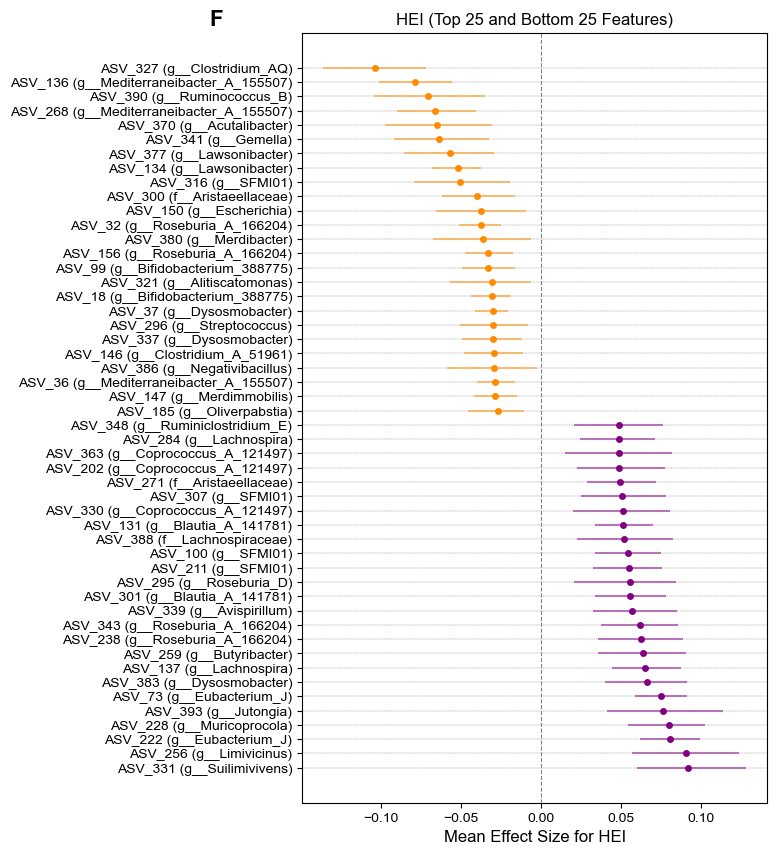

In [13]:
birdman_plot_single_var(
    beta_var,
    var,
    action="plot",
    n=25,
    plot_path=None,  # "../../figures/birdman_analysis/beta_var_HEI.png",
    annotate_plot_args={"text": "F", "textpos": (-0.2, 1.03)},
)

In [14]:
significant_feats = birdman_plot_single_var(
    beta_var, var, action="get_top_n", n=50
)  # ['Taxon'].values
significant_feats.head()

,Feature,Intercept_mean,HEI_mean,Intercept_std,HEI_std,Intercept_hdi,HEI_hdi,Taxon,lower,upper,credible
0,74923f4bbde849e27fc4eda25d757e2a,-2.659340,-0.103487,0.994548,0.017324,"(-4.45757, -0.787285)","(-0.135815, -0.0718401)",d__Bacteria; p__Bacillota_I; c__Bacilli_A; o__...,0.032328,0.031647,yes
1,fea3411c847e6627afb5e78b88e2e9af,-1.244603,-0.078480,0.699838,0.012130,"(-2.59101, 0.0056831)","(-0.100795, -0.0556635)",d__Bacteria; p__Bacillota_A_368345; c__Clostri...,0.022315,0.022816,yes
2,ad7bc2bb6e1ec90a9bc3c8949bce80d6,-2.398165,-0.070193,1.076214,0.018598,"(-4.5083, -0.500558)","(-0.103984, -0.0350166)",d__Bacteria; p__Bacillota_A_368345; c__Clostri...,0.033791,0.035176,yes
3,b6d740387526e21887b761f90fbc914a,-4.750752,-0.065892,0.738118,0.012871,"(-6.25761, -3.42578)","(-0.0895219, -0.0402139)",d__Bacteria; p__Bacillota_A_368345; c__Clostri...,0.023630,0.025678,yes
4,c5e3c5422835403541b0af331a2cc649,-4.894718,-0.064786,1.028811,0.017873,"(-6.79053, -2.85377)","(-0.0975652, -0.0301944)",d__Bacteria; p__Bacillota_A_368345; c__Clostri...,0.032780,0.034591,yes


In [15]:
significant_feats[significant_feats["Taxon"].str.contains("Faecalibacterium")][
    "Taxon"
].values

array(['d__Bacteria; p__Bacillota_A_368345; c__Clostridia_258483; o__Oscillospirales; f__Ruminococcaceae; g__Faecalibacterium; s__Faecalibacterium duncaniae'],
      dtype=object)

## Extracting Differentially Abundant Features from all variables (i.e., folders)

In [16]:
import os


def fetch_folders(directory):
    """
    Fetches all folders within the specified directory.

    Parameters:
    directory (str): The path to the directory to search for folders.

    Returns:
    List[str]: A list of folder names within the specified directory.
    """
    try:
        # Get the list of all items in the specified directory
        all_items = os.listdir(directory)
        # Filter and return only the directories
        folders = [
            item for item in all_items if os.path.isdir(os.path.join(directory, item))
        ]
        return folders
    except FileNotFoundError:
        print(f"The directory {directory} does not exist.")
        return []
    except PermissionError:
        print(f"Permission denied to access {directory}.")
        return []

#### Running for variables (for whom birdman was run)

In [49]:
folders = fetch_folders("outputs")

diffAbun_res = []
respectively_asvs = {}
corr_dict_all = {}
sq_corrs = []

for e, var in enumerate(sorted(folders)):
    beta_var = pd.read_csv(
        f"outputs/{var}/results/beta_var.tsv", sep="\t", index_col="Feature"
    )
    significant_feats = birdman_plot_single_var(beta_var, var, action="get_top_n", n=50)
    significant_feats["Taxon"] = significant_feats["Feature"].map(taxonomy_dict)

    if significant_feats.shape[0] > 0:
        birdman_plot_single_var(
            beta_var,
            var,
            action="plot",
            n=25,
            plot_path=f"./topn_plots/beta_var_{var}.png",
        )

        log_ratios, corr, corr_dict, num_numerator_asvs, num_denominator_asvs = (
            compute_log_ratios_using_significant_features(
                counts_data, var, significant_feats, meta, folders
            )
        )
        corr_dict_all[f"LR_({var})"] = corr_dict
        diffAbun_res.append(
            [
                var,
                len(significant_feats),
                corr,
                num_numerator_asvs,
                num_denominator_asvs,
            ]
        )

        respectively_asvs[var] = significant_feats["Feature"].values

        if e == 0 and log_ratios is not None:
            lr = log_ratios
        elif log_ratios is not None:
            lr = lr.merge(log_ratios[["sample-id", "Log Ratio"]], on="sample-id")
        lr.rename(columns={"Log Ratio": "LR_" + var}, inplace=True)

        ## For correlations with stool quality
        # if log_ratios is not None:
        #     sq = log_ratios.merge(stool_quality_meta, on="subject_app_key")
        #     corr_with_diarrhea = (
        #         sq[["Log Ratio", "diarrhea_proportion"]]
        #         .corr(method="pearson")
        #         .values[1, 0]
        #     )
        #     corr_with_great_stool = (
        #         sq[["Log Ratio", "great_stool_quality_proportion"]]
        #         .corr(method="pearson")
        #         .values[1, 0]
        #     )
        #     sq_corrs.append([var, corr_with_diarrhea, corr_with_great_stool])

    # significant_feats.to_csv(f"outputs/{var}/results/differential_taxa.tsv", sep="\t")

Common Samples: (973,) 	 Pearson Correlation CV_HEI: 0.32 	 P-value: 2.09e-24
Common Samples: (972,) 	 Pearson Correlation CV_fruits_fg_eaten: 0.38 	 P-value: 3.71e-34
Common Samples: (972,) 	 Pearson Correlation CV_meat_fg_eaten: 0.29 	 P-value: 5.12e-20
Common Samples: (973,) 	 Pearson Correlation CV_oils_nuts_fg_eaten: 0.36 	 P-value: 1.35e-31
Common Samples: (972,) 	 Pearson Correlation CV_vegetables_fg_eaten: 0.32 	 P-value: 2.55e-25
Common Samples: (970,) 	 Pearson Correlation HEI: 0.46 	 P-value: 9.92e-53
Common Samples: (973,) 	 Pearson Correlation alcohol_eaten: 0.32 	 P-value: 1.67e-24
Common Samples: (973,) 	 Pearson Correlation bread_fg_eaten: 0.32 	 P-value: 6.86e-24
Common Samples: (973,) 	 Pearson Correlation calcium_eaten: 0.26 	 P-value: 5.23e-17
Common Samples: (972,) 	 Pearson Correlation carb_eaten: 0.33 	 P-value: 3.22e-26
Common Samples: (973,) 	 Pearson Correlation coffee_fg_eaten: 0.32 	 P-value: 3.17e-25
Common Samples: (972,) 	 Pearson Correlation energy_kcal_

In [18]:
# lr[['LR_HEI',"shannon_entropy"]].corr(method="pearson")
lr[[i for i in lr.columns if "LR_" in i] + ["shannon_entropy"]].corr(method="spearman")[
    "shannon_entropy"
].sort_values()

LR_CV_vegetables_fg_eaten              -0.612830
LR_CV_fruits_fg_eaten                  -0.603693
LR_CV_HEI                              -0.580760
LR_CV_oils_nuts_fg_eaten               -0.535063
LR_fast_food_fg_eaten                  -0.524188
LR_carb_eaten                          -0.351088
LR_energy_kcal_eaten                   -0.226310
LR_bread_fg_eaten                      -0.209984
LR_CV_meat_fg_eaten                    -0.110637
LR_coffee_fg_eaten                     -0.099155
LR_fatty_acids_saturated_eaten         -0.076667
LR_alcohol_eaten                       -0.035919
LR_protein_eaten                        0.016786
LR_calcium_eaten                        0.027741
LR_meat_fg_eaten                        0.068047
LR_grains_cereals_fg_eaten              0.102327
LR_fat_eaten                            0.241656
LR_fatty_acids_monounsaturated_eaten    0.281177
LR_fatty_acids_polyunsaturated_eaten    0.436732
LR_phosphorus_eaten                     0.438505
LR_vegetables_fg_eat

In [18]:
# for var in sorted(folders)[:]:
#     k = pd.read_csv(
#         f"outputs/{var}/results/differential_taxa.tsv", sep="\t", index_col=0
#     )
#     Faecalibacterium = k[k["Taxon"].str.contains("Faecalibacterium")]
#     if Faecalibacterium.shape[0] > 0:
#         print(
#             var,
#             len(Faecalibacterium["Taxon"].values),
#             Faecalibacterium[f"{var}_mean"].values,
#             [i.split("; ")[-1] for i in Faecalibacterium["Taxon"].values],
#         )

In [19]:
diffAbun_res_df = pd.DataFrame(
    diffAbun_res,
    columns=[
        "variable",
        "num_feats",
        "corr",
        "num_numerator_asvs",
        "num_denominator_asvs",
    ],
)

print(
    diffAbun_res_df.sort_values("num_feats", ascending=False)["variable"][
        :15
    ].values.tolist()
)

diffAbun_res_df.sort_values(
    ["num_feats", "variable"], ascending=[False, False], inplace=True
)
diffAbun_res_df["variable_short"] = diffAbun_res_df["variable"].apply(process_string)

['CV_HEI', 'vegetables_fg_eaten', 'fiber_eaten', 'CV_fruits_fg_eaten', 'oils_fats_nuts', 'oils_nuts_fg_eaten', 'fast_food_fg_eaten', 'potassium_eaten', 'carb_eaten', 'vegetables_fruits', 'HEI', 'CV_vegetables_fg_eaten', 'CV_oils_nuts_fg_eaten', 'fruits_fg_eaten', 'meat_fg_eaten']


### Plotting Log Ratio Scatter

In [45]:
import scipy.stats as stats


def plot_log_ratio_scatter(
    lr,
    varname,
    log_ratio_label=None,
    ylabel=None,
    ax=None,
    textpos=[0.35, 0.95],
    cmap="BuGn",
):
    # Set up the figure and axis if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    ylabel = varname if ylabel is None else ylabel
    # Create scatter plot
    points = ax.scatter(
        # lr["Log Ratio"], lr[varname], c=lr["shannon_entropy"], s=10, cmap=cmap
        lr[f"LR_{log_ratio_label}"],
        lr[varname],
        c=lr["shannon_entropy"],
        s=10,
        cmap=cmap,
    )

    cbar = fig.colorbar(points, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label("Shannon Entropy")

    # Add regression line
    sns.regplot(
        data=lr,  # x="Log Ratio",
        x=lr[f"LR_{log_ratio_label}"],
        y=varname,
        scatter=False,
        color=".1",
        ax=ax,
    )

    # Calculate Pearson correlation
    # corr, p_value = stats.pearsonr(lr["Log Ratio"], lr[varname])
    corr, p_value = stats.pearsonr(lr[f"LR_{log_ratio_label}"], lr[varname])

    print(corr, p_value)

    # Annotate the plot with the R value in italics
    ax.text(
        textpos[0],
        textpos[1],
        f"$R = {corr:.2f}$",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.5),
    )

    # Set x-label and y-label
    ax.set_xlabel(f"Log Ratio$_\mathrm{{{log_ratio_label}}}$")
    ax.set_ylabel(ylabel)

    # Remove top and right spines
    sns.despine(ax=ax)

    return fig, ax

In [46]:
lr

,sample-id,LR_CV_HEI,subject_app_key,start_date,birthdate,gender,age,cohort,microbiome_tube,diet_restriction,...,LR_fruits_fg_eaten,LR_grains_cereals_fg_eaten,LR_meat_fg_eaten,LR_oils_fats_nuts,LR_oils_nuts_fg_eaten,LR_phosphorus_eaten,LR_potassium_eaten,LR_protein_eaten,LR_vegetables_fg_eaten,LR_vegetables_fruits
0,sample30489,-0.005932,nbr28t,2021-10-17,1980-09-22,male,41.0,cohort_b,30489,without_restriction,...,-0.231243,-0.265850,0.209195,-0.229885,-0.581043,-0.441087,-0.204435,0.088894,-0.317051,-0.288813
1,sample30706,-0.200528,mdfwwz,2022-06-27,1971-07-28,female,50.0,cohort_b,30706,without_restriction,...,0.001881,-0.622830,-0.106701,0.061580,-0.247058,-0.858488,-0.143528,-0.041079,-0.004227,-0.250092
2,sample30666,0.481654,kkx99g,2022-03-15,2000-09-03,male,21.0,cohort_b,30666,without_restriction,...,-0.533271,-0.016135,0.475694,-0.562006,-0.775909,-0.071777,-0.575095,0.480548,-0.590705,-0.598155
3,sample15977,0.309789,ta3d4k,2020-08-23,1998-01-18,female,21.0,cohort_b,15977,without_restriction,...,-0.424053,-0.190844,0.382083,-0.459119,-0.653340,-0.449683,-0.377111,0.165005,-0.229207,-0.596630
4,sample30750,0.252458,wu4vxf,2022-07-25,1981-12-29,female,40.0,cohort_b,30750,without_restriction,...,-0.437908,-0.999331,0.514910,-0.298314,-0.387255,-0.954243,-0.352588,0.508268,-0.360733,-0.601443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,sample30760,0.681897,rqqbnn,2022-08-16,2001-07-11,female,20.0,cohort_b,30760,non_dairy,...,-0.346389,0.248922,-0.247732,-0.716863,-0.793916,-0.785269,-0.718275,-0.038277,-0.854861,-0.855051
935,sample1116,-0.223211,7qq56f,2019-02-15,1991-04-29,male,27.0,cohort_b,1116,without_restriction,...,0.172161,-0.114548,-0.187343,-0.097262,-0.109019,-0.342839,-0.049789,0.269324,0.092273,0.095783
936,sample30810,-0.409793,e6scbx,2022-10-09,1963-08-02,female,59.0,cohort_b,30810,without_restriction,...,-0.284408,-0.984206,0.373157,-0.254261,-0.471238,-1.294833,-0.402690,-0.203679,-0.344344,-0.671768
937,sample30731,0.307810,ebf8qt,2022-06-05,1969-08-06,male,52.0,cohort_b,30731,without_restriction,...,-0.482727,-1.296591,0.596963,-0.615013,-0.339884,-0.801954,0.032622,0.422913,-0.653808,-0.624651


0.45500830640043466 3.6084062337130225e-49
-0.2821335295962259 1.2119844476713186e-18


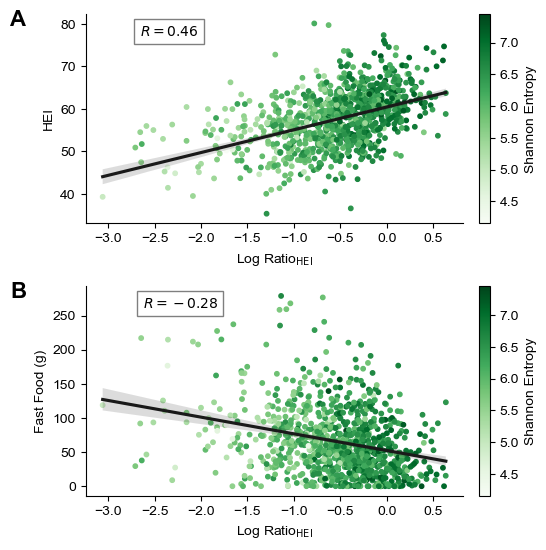

In [47]:
import matplotlib.gridspec as gridspec

# Create a figure with GridSpec
fig = plt.figure(figsize=(9, 5.6))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 1])

# Second column: Plot C (top right)
ax2 = fig.add_subplot(gs[0, 0])  # Place in the top right (first row, second column)
plot_log_ratio_scatter(
    lr, "HEI", log_ratio_label="HEI", ax=ax2, textpos=(0.3, 0.95), cmap="Greens"
)
ax2.text(
    -0.2,
    1.02,
    "A",
    transform=ax2.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)

# Second column: Plot D (bottom right)
ax3 = fig.add_subplot(gs[1, 0])  # Place in the bottom right (second row, second column)
plot_log_ratio_scatter(
    lr,
    "fast_food_fg_eaten",
    log_ratio_label="HEI",
    ylabel="Fast Food (g)",
    ax=ax3,
    textpos=(0.35, 0.95),
    cmap="Greens",
)
ax3.text(
    -0.2,
    1.02,
    "B",
    transform=ax3.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left",
)

# Adjust layout to avoid overlaps
plt.tight_layout()
fig.savefig(
    "../../figures/birdman_analysis/log_ratio_HEI_fast_food.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [24]:
# fig, ax = plt.subplots(figsize=(2, 6))
# sns.barplot(data=data_plot_1,
#             y='variable_short', x='num_feats', color='purple', alpha=0.5, ax=ax)
# ax.set_xlabel('No. of Differentially Abundant\nTaxa (out of 100)')
# ax.set_ylabel('')
# ax.text(-0.5, 1.02, 'A', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
# sns.despine()

### Creating Mirror Barplot

In [23]:
diffAbun_res_df

,variable,num_feats,corr,num_numerator_asvs,num_denominator_asvs,variable_short
28,vegetables_fruits,100,0.459138,50.0,50.0,Vegetables Fruits
27,vegetables_fg_eaten,100,0.376306,50.0,50.0,Vegetables
25,potassium_eaten,100,0.362981,70.0,30.0,Potassium
23,oils_nuts_fg_eaten,100,0.400086,53.0,47.0,Oils Nuts
22,oils_fats_nuts,100,0.371320,60.0,40.0,Oils Fats Nuts
18,fruits_fg_eaten,100,0.346118,61.0,39.0,Fruits
17,fiber_eaten,100,0.404252,50.0,50.0,Fiber
12,fast_food_fg_eaten,100,0.377371,26.0,74.0,Fast Food
9,carb_eaten,100,0.330589,24.0,76.0,Carb
5,HEI,100,0.463124,50.0,50.0,HEI


In [24]:
def create_mirror_barplot(
    df,
    variable_col="variable_short",
    numerator_col="num_numerator_asvs",
    denominator_col="num_denominator_asvs",
    ax=None,
    title="Numerator vs Denominator Counts",
    bar_alpha=0.3,
    text_size=8,
    panel_text="E",
    panel_pos=(-1, 1.02),
):
    """
    Create a mirror barplot showing numerator and denominator counts.

    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe containing the data
    variable_col : str
        Column name containing variable names
    numerator_col : str
        Column name containing numerator counts
    denominator_col : str
        Column name containing denominator counts
    figsize : tuple
        Figure size as (width, height)
    title : str
        Title of the plot
    bar_alpha : float
        Transparency of the bars (0-1)
    text_size : int
        Size of the text labels
    panel_text : str
        Text to display at the top left of the panel

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    df = df.copy()
    # df = df.sort_values(['num_feats', 'num_numerator_asvs', 'num_denominator_asvs', variable_col], ascending=[True, True, True, True])
    df = df.sort_values(["num_numerator_asvs", "num_denominator_asvs", variable_col])

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 7))

    # Create both barplots
    ax.barh(
        df[variable_col],
        df[numerator_col],
        height=0.8,
        color="blue",
        alpha=bar_alpha,
        label="Numerator",
    )
    ax.barh(
        df[variable_col],
        -df[denominator_col],
        height=0.8,
        color="darkorange",
        alpha=bar_alpha,
    )

    # Add vertical dashed grid lines
    ax.xaxis.grid(
        True, linestyle="dotted", which="both", color="gray", alpha=0.7, zorder=2
    )

    # Remove axis labels and spines
    ax.set_xticklabels([str(int(abs(x))) for x in ax.get_xticks()])
    ax.set_yticks([])
    ax.spines[
        [
            "right",
            "top",
            "left",
        ]
    ].set_visible(False)

    # Put variable names in the center
    for i, var_name in enumerate(df[variable_col]):
        ax.text(
            0,
            i,
            var_name,
            ha="center",
            va="center",
            fontweight="bold",
            fontsize=text_size,
            alpha=0.8,
        )

    # Add labels for the sides
    max_value = max(df[numerator_col].max(), df[denominator_col].max())
    ax.text(
        -max_value * 0.8,
        len(df) - 2,
        "Denominator\nASVs",
        color="darkorange",
        ha="center",
        va="center",
        weight="bold",
        fontsize=text_size + 2,
    )
    ax.text(
        max_value * 0.7,
        2,
        "Numerator\nASVs",
        color="blue",
        ha="center",
        va="center",
        weight="bold",
        fontsize=text_size + 2,
    )

    # Add panel text at top left
    ax.text(
        panel_pos[0],
        panel_pos[1],
        panel_text,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="left",
    )

    # Set title
    # ax.set_title(title, pad=10, weight='bold')

    # Adjust layout
    return ax

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_58508/2417806554.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([str(int(abs(x))) for x in ax.get_xticks()])


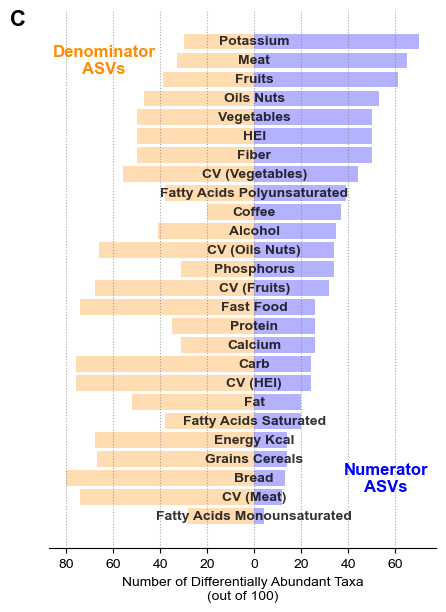

In [25]:
fig, ax = plt.subplots(figsize=(5, 7))
mirror_plot_data = diffAbun_res_df[diffAbun_res_df["num_feats"] > 10]
mirror_plot_data = mirror_plot_data[
    ~mirror_plot_data["variable"].isin(["vegetables_fruits", "oils_fats_nuts"])
]
create_mirror_barplot(
    mirror_plot_data,
    ax=ax,
    # title='Number of Differentially Abundant ASVs',
    text_size=10,
    panel_text="C",
    panel_pos=(-0.1, 1),
)
ax.set_xlabel("Number of Differentially Abundant Taxa\n(out of 100)")
fig.savefig(
    "../../figures/birdman_analysis/diff_abun_counts.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Creating Clustermap of Log Ratios

In [26]:
def correlation_dict_to_df(data):
    """
    Convert nested correlation dictionary to pandas DataFrame.
    """
    records = []

    for model, features in data.items():
        if features is not None:
            for feature, metrics in features.items():
                if metrics is not None:
                    record = {
                        "model": model,
                        "feature": feature,
                        "correlation": metrics["correlation"],
                        "pvalue": metrics["pvalue"],
                    }
                    records.append(record)

    return pd.DataFrame(records)

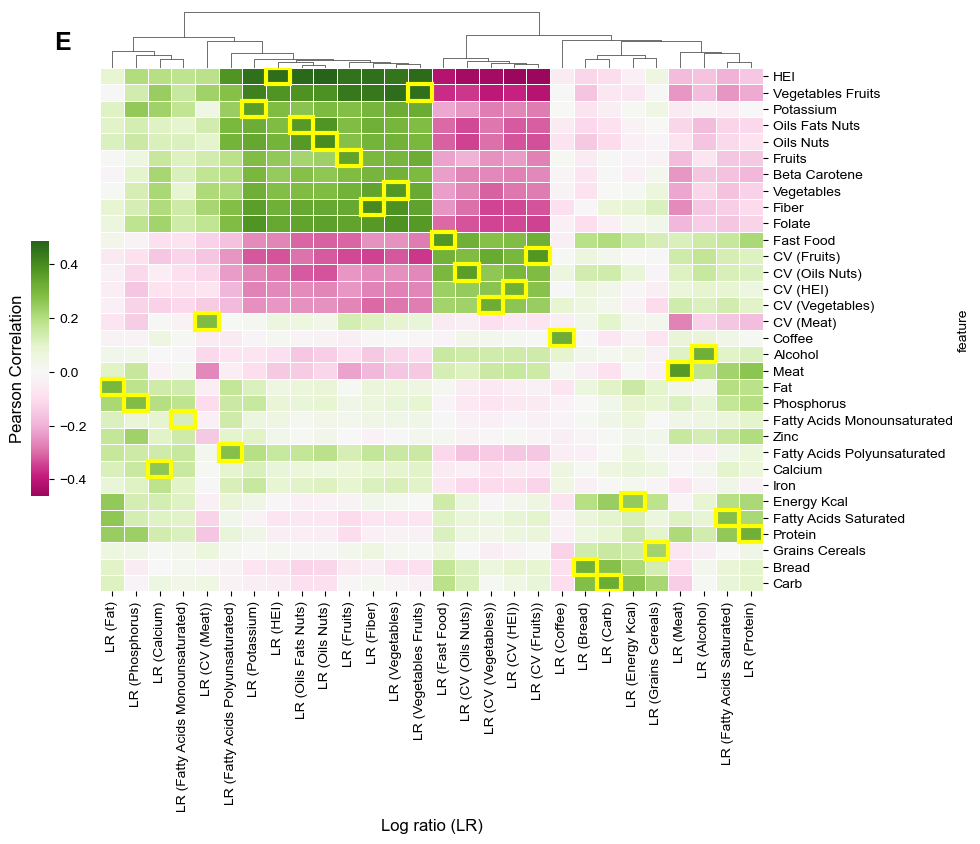

In [27]:
import matplotlib.patches as patches


corr_df_all = correlation_dict_to_df(corr_dict_all)  # pd.DataFrame(corr_dict_all)
corr_df_all = corr_df_all.pivot(index="feature", columns="model", values="correlation")

## drop all columns with any na
corr_df_all = corr_df_all.dropna(axis=1)

corr_df_all.index = corr_df_all.index.map(lambda i: process_string(i, newLineSep=4))
# corr_df_all.columns = corr_df_all.columns.map(lambda i: process_string(i, newLineSep=4))
corr_df_all.columns = corr_df_all.columns.map(
    lambda i: "LR (" + process_string(i[4:-1], newLineSep=6) + ")"
)

g = sns.clustermap(
    corr_df_all,
    cmap="PiYG",
    center=0,
    linewidths=0.5,
    figsize=(9, 8.5),
    dendrogram_ratio=(0, 0.1),
    cbar_pos=(-0.06, 0.41, 0.02, 0.3),  # Adjust position (x, y, width, height)
    cbar_kws={
        "shrink": 0.2,
    },  # Reduce thickness
)

g.cax.set_ylabel(
    "Pearson Correlation",
    rotation=90,
    fontsize=12,
    labelpad=-55,
)

# Get the reordered row and column labels after clustering
clustered_rows = g.dendrogram_row.reordered_ind
clustered_cols = g.dendrogram_col.reordered_ind

# Get the row and column labels after clustering
clustered_row_labels = corr_df_all.index[clustered_rows]
clustered_col_labels = corr_df_all.columns[clustered_cols]

# List of variable names to highlight
variable_names = [
    i for i in corr_df_all.index if "LR (" + i + ")" in corr_df_all.columns
]

# Get the heatmap axis
ax = g.ax_heatmap
ax.set_xlabel("Log ratio (LR)", rotation=0, fontsize=12, labelpad=5)

# Mark Panel text
ax.text(
    -0.07,
    1.07,
    "E",
    transform=ax.transAxes,
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left",
)

# Loop through variable names and highlight the corresponding cells
for var_name in variable_names:
    # Find the new row and column indices in the clustered heatmap
    clustered_row_idx = list(clustered_row_labels).index(var_name)
    clustered_col_idx = list(clustered_col_labels).index("LR (" + var_name + ")")

    # Add a rectangle patch for each cell
    highlight_patch = patches.Rectangle(
        (clustered_col_idx, clustered_row_idx),
        1,
        1,
        fill=False,
        edgecolor="yellow",
        lw=3,
    )
    ax.add_patch(highlight_patch)

plt.savefig(
    "../../figures/birdman_analysis/diff_abun_clustermap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Common ASVs


In [28]:
print(
    len(
        set(respectively_asvs["HEI"]).intersection(
            set(respectively_asvs["fast_food_fg_eaten"])
        )
    )
)
print(len(set(respectively_asvs["HEI"]).intersection(set(respectively_asvs["CV_HEI"]))))
print(
    len(
        set(respectively_asvs["HEI"]).intersection(
            set(respectively_asvs["fiber_eaten"])
        )
    )
)
print(
    len(
        set(respectively_asvs["HEI"]).intersection(
            set(respectively_asvs["alcohol_eaten"])
        )
    )
)
print(
    len(
        set(respectively_asvs["HEI"]).intersection(
            set(respectively_asvs["coffee_fg_eaten"])
        )
    )
)

50
52
58
31
20


In [29]:
print(len(respectively_asvs["HEI"]))

100


In [30]:
corr_df = pd.read_csv("../../data/partial_corr_across_feats.csv", index_col=0)
corr_df.rename(columns={"microbe": "taxonID"}, inplace=True)

corr_df["feature_shortname"] = corr_df["feature"].apply(lambda x: process_string(x))
corr_df["microbe"] = corr_df["taxonID"].map(
    lambda i: otuID_taxonomy.loc[i].values[0].replace("; ", ";")
)

corr_df

,n,r,CI95%,p-val,taxonID,feature,corrected_pval,feature_shortname,microbe
spearman,973,0.261830,[0.2 0.32],1.100179e-16,7dfa96abfa7484bb6c9cfa90dc9b606f,HEI,1.377203e-12,HEI,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
spearman,973,-0.256812,[-0.31 -0.2 ],4.332330e-16,c5e3c5422835403541b0af331a2cc649,HEI,2.711606e-12,HEI,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
spearman,973,-0.248682,[-0.31 -0.19],3.749649e-15,c82032c40c98975f71892e4be561c87a,HEI,1.564603e-11,HEI,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
spearman,973,-0.235430,[-0.29 -0.18],1.074091e-13,e788d109a82f218babace41804c108f4,HEI,3.016246e-10,HEI,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
spearman,973,-0.234962,[-0.29 -0.17],1.204763e-13,ceca42862d54f453bbe3f3608dd48f30,HEI,3.016246e-10,HEI,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
...,...,...,...,...,...,...,...,...,...
spearman,973,0.104325,[0.04 0.17],1.131647e-03,5860dac317300b1fe6094e958240cc7f,CV_water_fg_eaten,9.997733e-01,CV (Water),d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
spearman,973,-0.122907,[-0.18 -0.06],1.232724e-04,4c855814a58f4f324e8f0cfaab222e1f,CV_alcohol_fg_eaten,8.437776e-01,CV (Alcohol),d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
spearman,973,-0.110606,[-0.17 -0.05],5.549006e-04,514b34f09e4acd2397d38273c630d338,CV_alcohol_fg_eaten,8.437776e-01,CV (Alcohol),d__Bacteria;p__Bacillota_A_368345;c__Clostridi...
spearman,973,-0.100197,[-0.16 -0.04],1.771593e-03,5034598009be77942a505e7c9978b06b,CV_alcohol_fg_eaten,8.437776e-01,CV (Alcohol),d__Bacteria;p__Bacillota_A_368345;c__Clostridi...


In [31]:
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def create_bipartite_graph(
    df,
    microbe_col="microbe",
    feature_col="feature",
    weight_col="r",
    node_size=[50, 50],
    pval_col="p-val",
    hide_microbe_labels=True,
    ancestral_taxa_col="ancestral_taxa",
    ancestry_color_dict=None,
    figsize=(12, 8),
    show_edge_colors=True,
    min_edge_width=0.1,
    max_edge_width=2.0,
    edge_width_scale=1.0,
    layout="spring",
    annotate_plot_args=None,
    save_fig_path=None,
):
    """
    Creates and visualizes a bipartite graph from the given correlation dataframe.

    Parameters:
    df (pd.DataFrame): The dataframe containing correlation data.
    microbe_col (str): Column name for microbes.
    feature_col (str): Column name for features.
    weight_col (str): Column name for edge weights (correlation coefficient).
    pval_col (str): Column name for p-values.
    hide_microbe_labels (bool): If True, hide the labels for microbe nodes.
    ancestral_taxa_col (str): Column name for ancestral taxa information.
    ancestry_color_dict (dict): Dictionary mapping ancestral taxa to colors. If None, colors are auto-generated.
    figsize (tuple): Figure size in inches (width, height).
    show_edge_colors (bool): If True, show edge colors based on correlation direction. If False, use a single color.
    min_edge_width (float): Minimum edge width.
    max_edge_width (float): Maximum edge width.
    edge_width_scale (float): Scaling factor for edge widths.
    layout (str): The layout algorithm to use. Options: 'spring', 'circular', 'random', 'shell', 'kamada_kawai', 'spectral'.
    """
    # Create a bipartite graph
    B = nx.Graph()

    # Add nodes for microbes and features
    microbes = df[microbe_col].unique()
    features = df[feature_col].unique()

    B.add_nodes_from(microbes, bipartite=0)  # Set of microbes
    B.add_nodes_from(features, bipartite=1)  # Set of features

    # Add edges with weights corresponding to the correlation coefficient 'weight_col'
    for _, row in df.iterrows():
        B.add_edge(
            row[microbe_col],
            row[feature_col],
            weight=row[weight_col],
            pval=row[pval_col],
        )

    # Create a new figure with specified size
    plt.figure(figsize=figsize)

    # Choose the layout algorithm
    if layout == "spring":
        pos = nx.spring_layout(B, seed=42)
    elif layout == "circular":
        pos = nx.circular_layout(B)
    elif layout == "random":
        pos = nx.random_layout(B)
    elif layout == "shell":
        pos = nx.shell_layout(B)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(B)
    elif layout == "spectral":
        pos = nx.spectral_layout(B)
    else:
        raise ValueError(
            "Invalid layout option. Choose from 'spring', 'circular', 'random', 'shell', 'kamada_kawai', 'spectral'."
        )

    # Generate a color map for ancestral taxa if not provided
    unique_taxa = df[ancestral_taxa_col].unique()
    if ancestry_color_dict is None:
        color_map = plt.cm.get_cmap("Set1")
        ancestry_color_dict = {
            taxa: color_map(i / len(unique_taxa)) for i, taxa in enumerate(unique_taxa)
        }

    print("Total unique taxa:", len(unique_taxa))

    # Draw nodes with much smaller node size and color by ancestral taxa
    for taxa in unique_taxa:
        taxa_microbes = df[df[ancestral_taxa_col] == taxa][microbe_col].unique()
        nx.draw_networkx_nodes(
            B,
            pos,
            nodelist=taxa_microbes,
            node_color=ancestry_color_dict[taxa],
            label=taxa,
            node_size=node_size[1],
        )

    nx.draw_networkx_nodes(
        B,
        pos,
        nodelist=features,
        node_color="gold",
        label="Features",
        node_size=node_size[0],
    )

    # Draw edges - use edge color to represent correlation direction if show_edge_colors is True
    edges = B.edges(data=True)
    if show_edge_colors:
        edge_colors = ["cyan" if edge[2]["weight"] > 0 else "magenta" for edge in edges]
    else:
        edge_colors = "gray"  # Use a single color if show_edge_colors is False

    # Adjust edge thickness based on absolute correlation value
    weights = [abs(edge[2]["weight"]) for edge in edges]

    # Normalize weights to the specified range and apply scaling
    max_weight = max(weights)
    min_weight = min(weights)
    if max_weight != min_weight:
        normalized_weights = [
            (
                (w - min_weight)
                / (max_weight - min_weight)
                * (max_edge_width - min_edge_width)
                + min_edge_width
            )
            * edge_width_scale
            for w in weights
        ]
    else:
        normalized_weights = [min_edge_width * edge_width_scale for _ in weights]

    nx.draw_networkx_edges(
        B,
        pos,
        edgelist=edges,
        edge_color=edge_colors,
        width=normalized_weights,
        alpha=0.5,
    )

    # Draw labels with smaller font size for features
    texts = []
    if hide_microbe_labels:
        for node in features:
            x, y = pos[node]
            texts.append(plt.text(x, y, node, fontsize=10))
    else:
        for node in microbes:
            x, y = pos[node]
            texts.append(plt.text(x, y, node, fontsize=6))
        for node in features:
            x, y = pos[node]
            texts.append(plt.text(x, y, node, fontsize=8))

    # Adjust text to avoid overlap
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray"))

    # Get current axis
    ax = plt.gca()

    # First legend: node types (ancestral taxa and features) with different marker sizes
    taxa_legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markersize=6,
            label=taxa,
        )
        for taxa, color in ancestry_color_dict.items()
    ]
    # Larger marker size for "Features"
    taxa_legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="gold",
            markersize=10,
            label="Features",
        )
    )
    legend1 = ax.legend(
        handles=taxa_legend_handles,
        bbox_to_anchor=(0.94, 1),
        loc="upper left",
        title="Node Types",
        frameon=False,
    )

    # Add the first legend to the axes
    ax.add_artist(legend1)

    # Create a separate legend for edge correlation directions
    correlation_legend_handles = [
        Line2D([0], [0], color="cyan", lw=2, label="Positive Correlation"),
        Line2D([0], [0], color="magenta", lw=2, label="Negative Correlation"),
    ]
    plt.legend(
        handles=correlation_legend_handles,
        loc="lower left",
        bbox_to_anchor=(0.95, 0.15),
        title="Correlation Direction",
        frameon=False,
    )

    if annotate_plot_args is not None:
        ax.text(
            annotate_plot_args["textpos"][0],
            annotate_plot_args["textpos"][1],
            annotate_plot_args["text"],
            transform=ax.transAxes,
            fontsize=16,
            fontweight="bold",
            va="top",
            ha="left",
        )

    # Title and formatting
    # plt.title(f"Bipartite Graph of Microbes and Features ({layout} layout)")
    plt.tight_layout()
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)

    if save_fig_path:
        plt.savefig(save_fig_path, dpi=300, bbox_inches="tight")

In [32]:
[(i, len(l)) for i, l in respectively_asvs.items()]

[('CV_HEI', 100),
 ('CV_fruits_fg_eaten', 100),
 ('CV_meat_fg_eaten', 86),
 ('CV_oils_nuts_fg_eaten', 100),
 ('CV_vegetables_fg_eaten', 100),
 ('HEI', 100),
 ('alcohol_eaten', 76),
 ('bread_fg_eaten', 93),
 ('calcium_eaten', 57),
 ('carb_eaten', 100),
 ('coffee_fg_eaten', 57),
 ('energy_kcal_eaten', 82),
 ('fast_food_fg_eaten', 100),
 ('fat_eaten', 72),
 ('fatty_acids_monounsaturated_eaten', 32),
 ('fatty_acids_polyunsaturated_eaten', 77),
 ('fatty_acids_saturated_eaten', 58),
 ('fiber_eaten', 100),
 ('fruits_fg_eaten', 100),
 ('grains_cereals_fg_eaten', 81),
 ('iron_eaten', 7),
 ('meat_fg_eaten', 98),
 ('oils_fats_nuts', 100),
 ('oils_nuts_fg_eaten', 100),
 ('phosphorus_eaten', 65),
 ('potassium_eaten', 100),
 ('protein_eaten', 61),
 ('vegetables_fg_eaten', 100),
 ('vegetables_fruits', 100),
 ('zinc_eaten', 1)]

In [33]:
respectively_asvs.keys()

dict_keys(['CV_HEI', 'CV_fruits_fg_eaten', 'CV_meat_fg_eaten', 'CV_oils_nuts_fg_eaten', 'CV_vegetables_fg_eaten', 'HEI', 'alcohol_eaten', 'bread_fg_eaten', 'calcium_eaten', 'carb_eaten', 'coffee_fg_eaten', 'energy_kcal_eaten', 'fast_food_fg_eaten', 'fat_eaten', 'fatty_acids_monounsaturated_eaten', 'fatty_acids_polyunsaturated_eaten', 'fatty_acids_saturated_eaten', 'fiber_eaten', 'fruits_fg_eaten', 'grains_cereals_fg_eaten', 'iron_eaten', 'meat_fg_eaten', 'oils_fats_nuts', 'oils_nuts_fg_eaten', 'phosphorus_eaten', 'potassium_eaten', 'protein_eaten', 'vegetables_fg_eaten', 'vegetables_fruits', 'zinc_eaten'])

In [34]:
selected_vars = [
    "fiber_eaten",
    "vegetables_fg_eaten",
    "fruits_fg_eaten",
    "HEI",
    "energy_kcal_eaten",
    "oils_nuts_fg_eaten",
    "fast_food_fg_eaten",
    "meat_fg_eaten",
    "bread_fg_eaten",
    #'grains_cereals_fg_eaten',
    "coffee_fg_eaten",
    "alcohol_eaten",
    "CV_fruits_fg_eaten",
    "CV_potassium_eaten",
    #'CV_HEI',
    # 'CV_meat_fg_eaten',
    # 'CV_oils_nuts_fg_eaten',
    # 'CV_vegetables_fg_eaten',
    #'fatty_acids_polyunsaturated_eaten',
]


# selected_vars = list(respectively_asvs.keys())

subset = corr_df[corr_df["feature"].isin(selected_vars)]

### Option1: Filter by r > 0.15
# significant_microbes = subset[subset['r'].abs() > 0.15]['microbe'].unique()
### Option2: Filter by unique ASVs from the values of respective_asv dictionary
all_selected_vars_asvs = set()
for var, asv_list in respectively_asvs.items():
    if var in selected_vars:
        all_selected_vars_asvs.update(asv_list)
print(f"Total number of unique ASVs: {len(all_selected_vars_asvs)}")

significant_microbes = (
    corr_df[corr_df["taxonID"].isin(all_selected_vars_asvs)]["microbe"]
    .unique()
    .tolist()
)

subset = subset[subset["microbe"].isin(significant_microbes)]


subset["ancestral_taxa"] = subset["microbe"].apply(
    lambda i: extract_taxonomy_level(i, "c")
)
# subset['ancestral_taxa'] = subset['ancestral_taxa'].map(lambda i: i.split("_")[0])

print("No. of unique Ancestral Taxa:", subset["ancestral_taxa"].nunique())
print("Unique Ancestral Taxa:", subset["ancestral_taxa"].unique())

print("subset.shape:", subset.shape)
print("total ASVs:", subset["microbe"].nunique())

Total number of unique ASVs: 317
No. of unique Ancestral Taxa: 9
Unique Ancestral Taxa: ['Clostridia_258483' 'Bacilli_A' 'Bacteroidia' 'Coriobacteriia'
 'Desulfovibrionia' 'Actinomycetes' 'Lentisphaeria' 'Gammaproteobacteria'
 'Negativicutes']
subset.shape: (20519, 10)
total ASVs: 145


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

Total unique taxa: 9


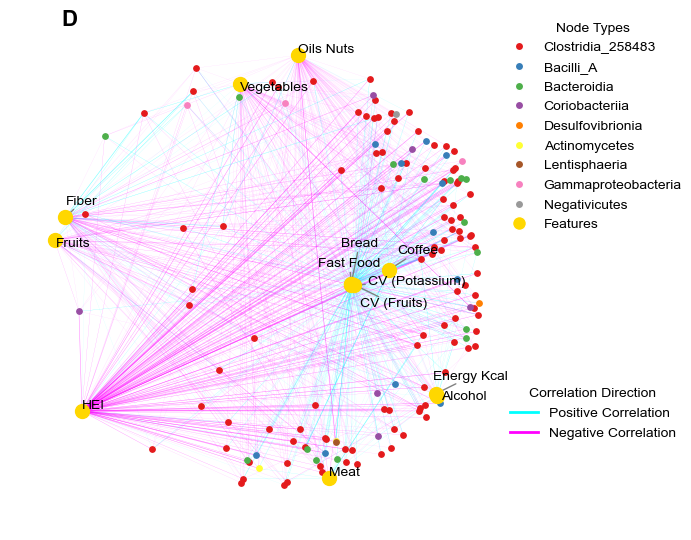

In [35]:
# ancestry_color_dict_phylum = {
#     'Firmicutes': 'lightblue',
#     'Actinobacteriota': 'pink',
#     'Bacteroidota': 'gold',
#     'Proteobacteria': 'cyan',
#     'Fusobacteriota':'lightgrey',
#     'Cyanobacteria':'lightgrey',
#     'Patescibacteria':'lightgrey',
#     'Desulfobacterota':'lightgrey'
# }

color_map = plt.cm.get_cmap("Set1")
ancestry_color_dict_phylum = {
    i: color_map(e) for e, i in enumerate(subset["ancestral_taxa"].unique())
}


create_bipartite_graph(
    subset,
    hide_microbe_labels=True,
    feature_col="feature_shortname",
    ancestral_taxa_col="ancestral_taxa",
    ancestry_color_dict=ancestry_color_dict_phylum,
    node_size=[100, 15],
    figsize=(7, 5.5),
    show_edge_colors=True,
    min_edge_width=0.1,
    max_edge_width=2.0,
    edge_width_scale=0.5,
    layout="spring",
    annotate_plot_args={"text": "D", "textpos": (0.1, 1.0)},
    save_fig_path="../../figures/birdman_analysis/network_class_level.png",
)

## Network at Genus Level

In [41]:
selected_vars = [
    "fiber_eaten",
    "vegetables_fg_eaten",
    "fruits_fg_eaten",
    "HEI",
    "energy_kcal_eaten",
    "oils_nuts_fg_eaten",
    "fast_food_fg_eaten",
    "meat_fg_eaten",
    "bread_fg_eaten",
    #'grains_cereals_fg_eaten',
    "coffee_fg_eaten",
    "alcohol_eaten",
    "CV_fruits_fg_eaten",
    "CV_potassium_eaten",
    #'CV_HEI',
    # 'CV_meat_fg_eaten',
    # 'CV_oils_nuts_fg_eaten',
    # 'CV_vegetables_fg_eaten',
    #'fatty_acids_polyunsaturated_eaten',
]


# selected_vars = list(respectively_asvs.keys())

subset = corr_df[corr_df["feature"].isin(selected_vars)]

### Option1: Filter by r > 0.15
# significant_microbes = subset[subset['r'].abs() > 0.15]['microbe'].unique()
### Option2: Filter by unique ASVs from the values of respective_asv dictionary
all_selected_vars_asvs = set()
for var, asv_list in respectively_asvs.items():
    if var in selected_vars:
        all_selected_vars_asvs.update(asv_list)
print(f"Total number of unique ASVs: {len(all_selected_vars_asvs)}")

significant_microbes = (
    corr_df[corr_df["taxonID"].isin(all_selected_vars_asvs)]["microbe"]
    .unique()
    .tolist()
)

subset = subset[subset["microbe"].isin(significant_microbes)]

subset["ancestral_taxa"] = subset["microbe"].apply(
    lambda i: extract_taxonomy_level(i, "g")
)
# subset['ancestral_taxa'] = subset['ancestral_taxa'].map(lambda i: i.split("_")[0])
subset["ancestral_taxa"] = subset["ancestral_taxa"].replace("", "Unclassified")

print("No. of unique Ancestral Taxa:", subset["ancestral_taxa"].nunique())
print("Unique Ancestral Taxa:", subset["ancestral_taxa"].unique())

print("subset.shape:", subset.shape)
print("total ASVs:", subset["microbe"].nunique())

Total number of unique ASVs: 317
No. of unique Ancestral Taxa: 108
Unique Ancestral Taxa: ['Eubacterium_J' 'Acutalibacter' 'Dysosmobacter' 'Unclassified'
 'Hydrogeniiclostridium' 'SFMI01' 'Merdibacter'
 'Mediterraneibacter_A_155507' 'Anaerotruncus' 'Lawsonibacter' 'Gemella'
 'Alitiscatomonas' 'Agathobaculum' 'Lentihominibacter' 'Hominilimicola'
 'Phocaeicola_A' 'Bariatricus' 'CAG-269' 'Adlercreutzia_A_404257'
 'Anaeromassilibacillus' 'Faecousia' 'Enterocloster' 'Thomasclavelia'
 'Lachnoclostridium_B' 'Butyricimonas' 'Merdimmobilis' 'Limiplasma'
 'Oliverpabstia' 'Alistipes_A_871400' 'Negativibacillus' 'Clostridium_AQ'
 'Paludihabitans' 'Agathobacter_164117' 'UBA5905' 'Ruminiclostridium_E'
 'Faecalibacterium' 'RUG13077' 'Porcincola' 'Dorea_A' 'Gemmiger_A_73129'
 'CAG-177' 'Blautia_A_141781' 'Clostridium_T' 'Lachnospira'
 'Parabacteroides_B_862066' 'Laedolimicola' 'Anaerobutyricum'
 'Anaerotardibacter' 'Hominibacterium' 'Borkfalkia' 'Holdemania'
 'Clostridium_A_51961' 'Brotaphodocola' 'Ho

In [43]:
subset.groupby(["microbe"])["ancestral_taxa"].apply(
    lambda i: i.value_counts().head(1).index[0]
).value_counts()

Unclassified            8
Lawsonibacter           5
Blautia_A_141781        5
Roseburia_A_166204      3
Bacteroides_H_857956    3
                       ..
Oribacterium            1
Oliverpabstia           1
Muricoprocola           1
Muricomes_149720        1
Victivallis             1
Name: ancestral_taxa, Length: 108, dtype: int64

In [44]:
subset["ancestral_taxa"].value_counts()

Unclassified              3550
Blautia_A_141781           936
Faecalibacterium           755
Faecousia                  714
Lawsonibacter              541
                          ... 
Gemella                     14
Lactococcus_A_346120         9
Bifidobacterium_388775       8
Muricomes_149720             5
Escherichia                  5
Name: ancestral_taxa, Length: 108, dtype: int64

In [45]:
subset[subset["ancestral_taxa"] == "Blautia"]["feature"].value_counts()

Series([], Name: feature, dtype: int64)

['Lawsonibacter', 'Blautia_A_141781', 'Roseburia_A_166204', 'Bacteroides_H_857956', 'Alistipes_A_871400', 'Gemmiger_A_73129', 'Dysosmobacter', 'Alitiscatomonas', 'Dorea_A', 'Streptococcus']


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

Total unique taxa: 11


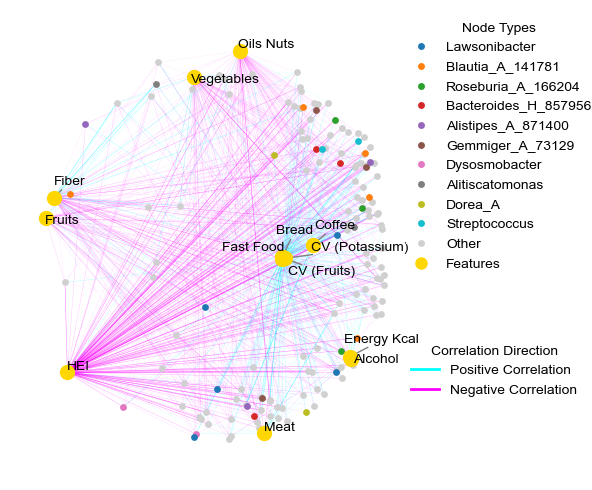

In [46]:
top_n_taxonomies = 10
# top_taxonomies = subset['ancestral_taxa'].value_counts().head(top_n_taxonomies + 1).index.tolist()
top_taxonomies = (
    subset.groupby(["microbe"])["ancestral_taxa"]
    .apply(lambda i: i.value_counts().head(1).index[0])
    .value_counts()
    .index.tolist()
)
if "Unclassified" in top_taxonomies:
    top_taxonomies.remove("Unclassified")
top_taxonomies = top_taxonomies[:top_n_taxonomies]
print(top_taxonomies)

subset["ancestral_taxa"] = subset["ancestral_taxa"].map(
    lambda i: i if i in top_taxonomies else "Other"
)

color_map = plt.cm.get_cmap("tab10")
# ancestry_color_dict_phylum = {i:color_map(e) if i in top_taxonomies else 'grey' for e,i in enumerate(subset['ancestral_taxa'].unique())}
ancestry_color_dict_phylum = {i: color_map(e) for e, i in enumerate(top_taxonomies)}

for i in subset["ancestral_taxa"].unique():
    if i not in top_taxonomies:
        ancestry_color_dict_phylum[i] = "#D0D0D0"

create_bipartite_graph(
    subset,
    hide_microbe_labels=True,
    feature_col="feature_shortname",
    ancestral_taxa_col="ancestral_taxa",
    ancestry_color_dict=ancestry_color_dict_phylum,
    node_size=[100, 15],
    figsize=(6, 5),
    show_edge_colors=True,
    min_edge_width=0.1,
    max_edge_width=2.0,
    edge_width_scale=0.5,
    layout="spring",
)